Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um001_crop/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um002/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um003/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um_crop/RDF.zarr


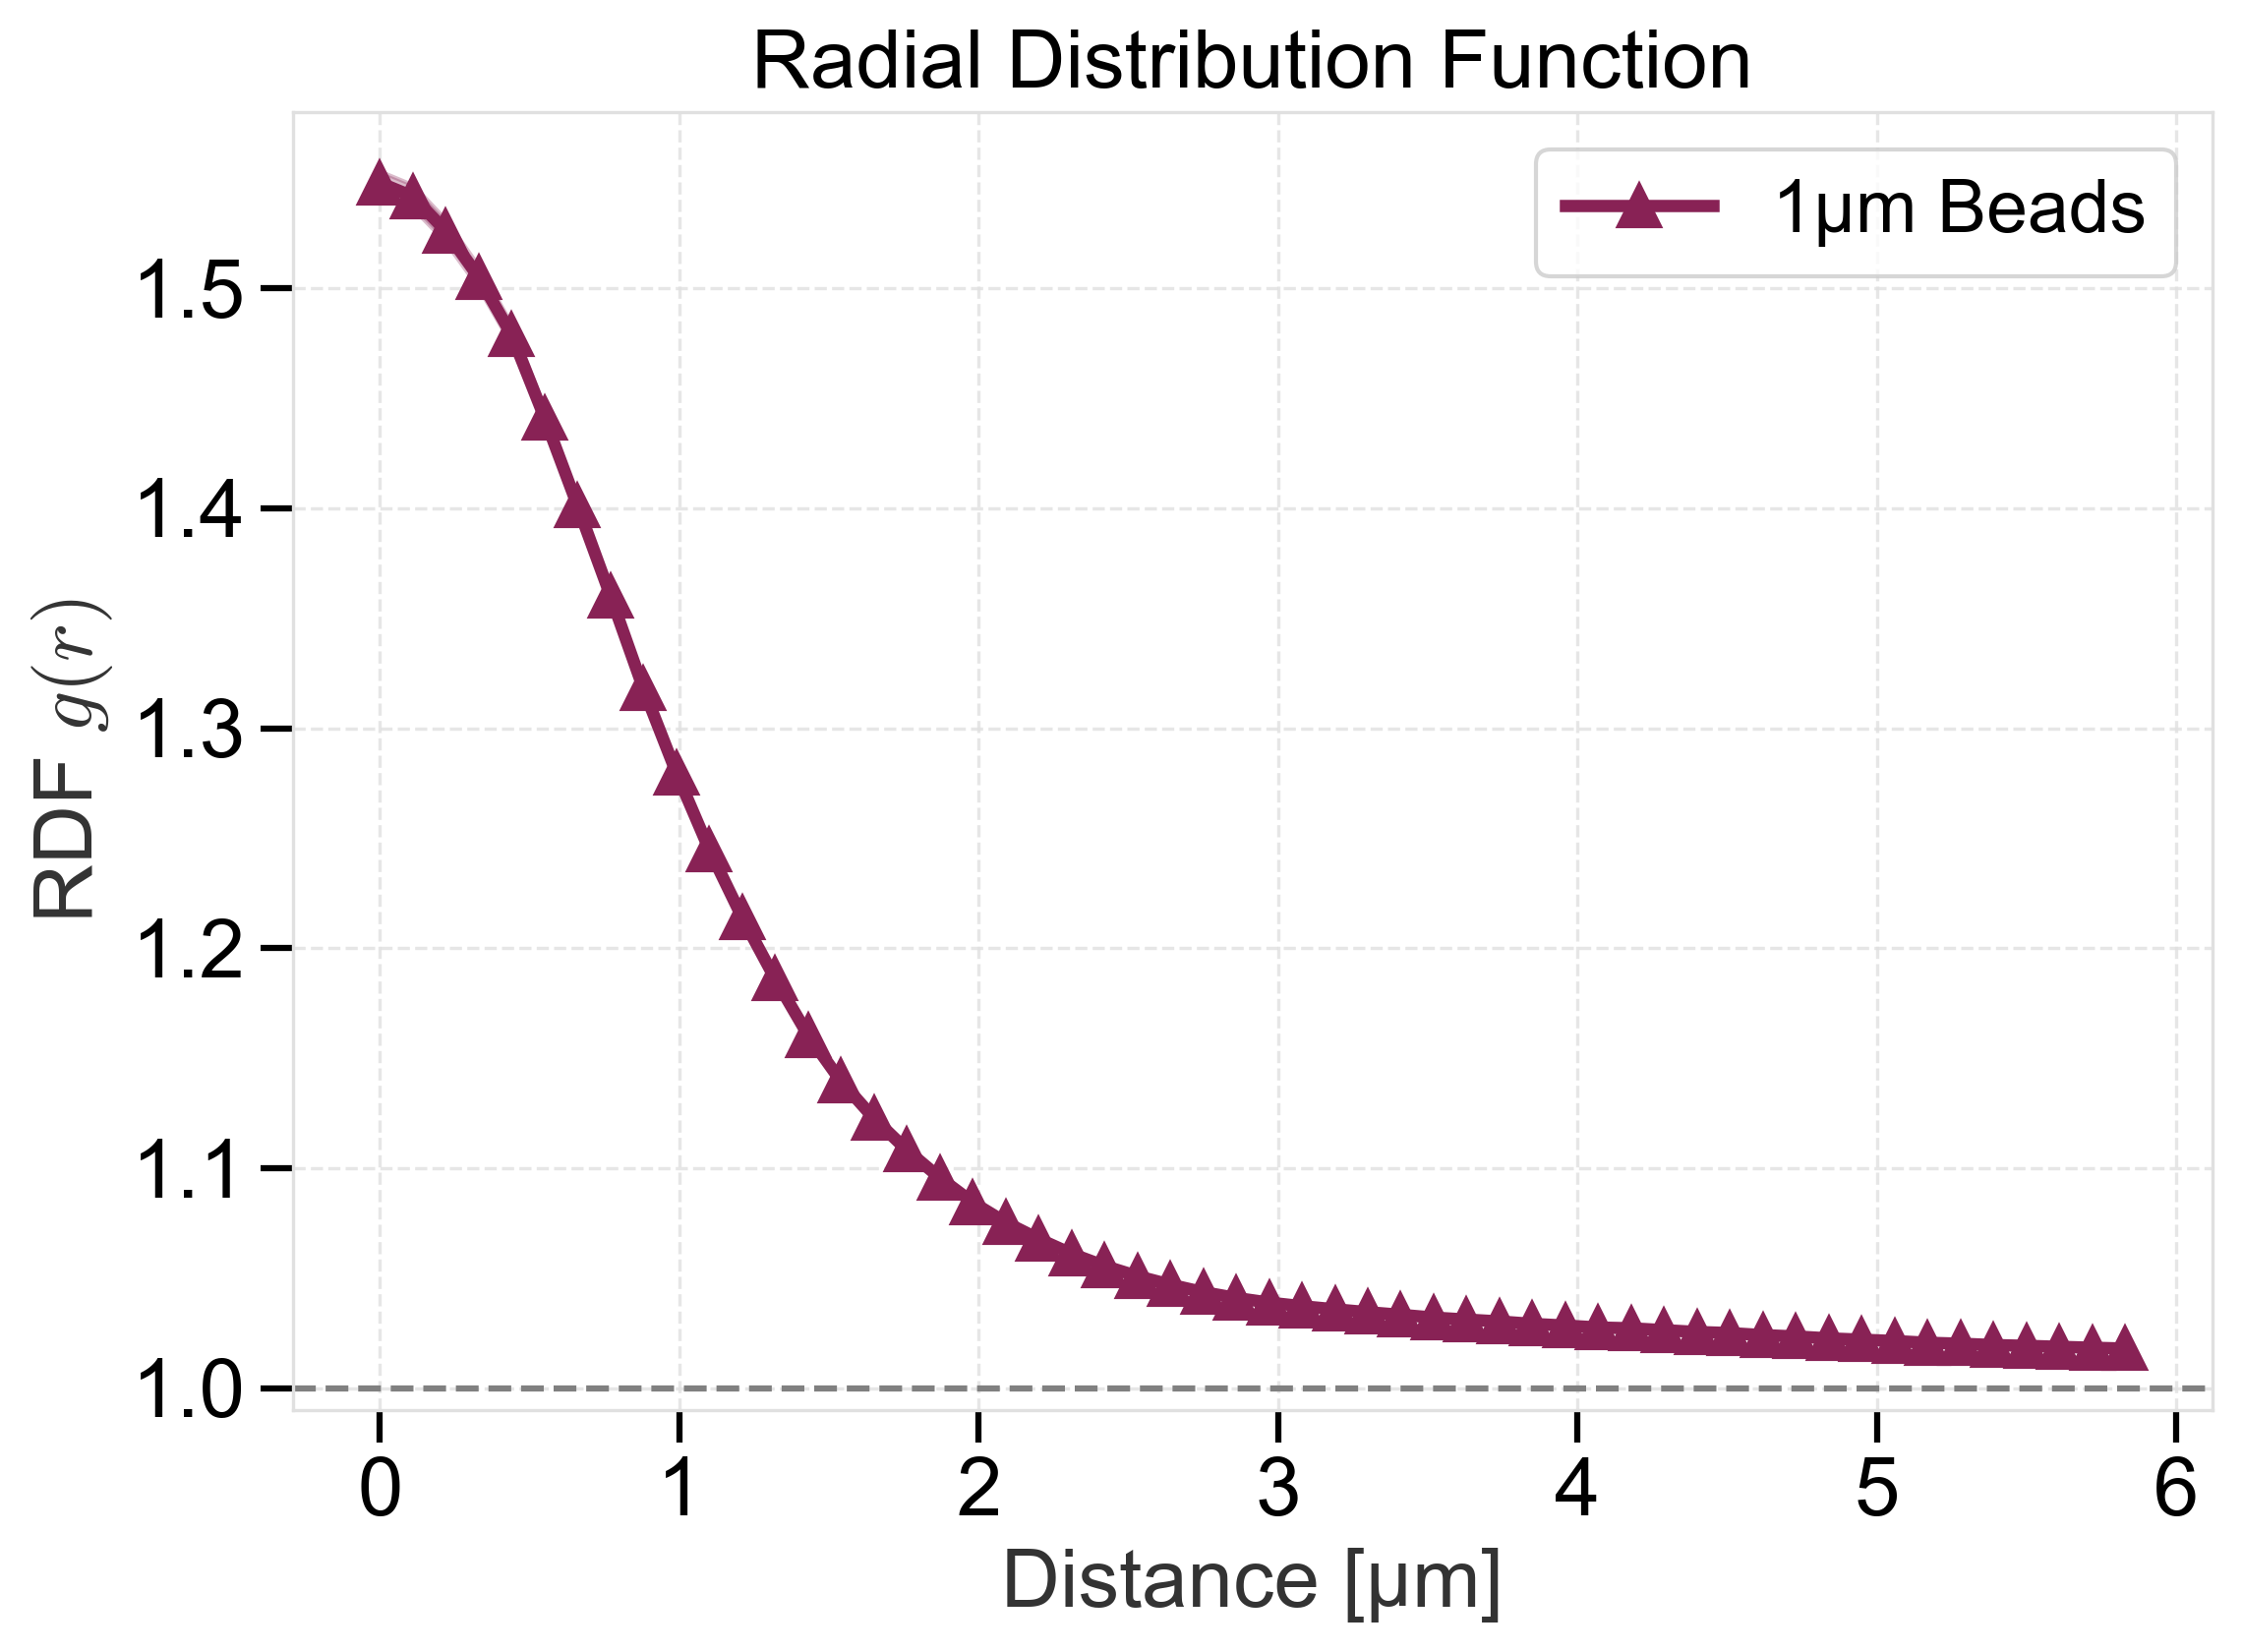

In [3]:
import zarr
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob

from pathlib import Path

sys.path.append(os.path.abspath(".."))

plt.style.use('../libs/my_style.mplstyle')

# 対象ディレクトリの検索
base_path = "/Volumes/data/Sasaki/MTsingleBeads/beads1um/*/*"
dirs = glob.glob(base_path)

rdf_list = []
for d in dirs:
    zarr_path = os.path.join(d, "RDF.zarr")
    # RDF.zarr が存在するものだけをロード
    if os.path.exists(zarr_path):
        print(f"Loading: {zarr_path}")
        rdf = zarr.open_array(zarr_path, mode='r')[:]
        rdf_list.append(rdf)

if len(rdf_list) > 0:
    # 全てのRDF配列を縦に結合 (Particle数 × 距離)
    all_rdfs = np.concatenate(rdf_list, axis=0)
    
    # x軸（距離）の計算
    max_r = all_rdfs.shape[1]
    scale = 0.11 # um/px (RDF.pyの設定に合わせる)
    r = np.arange(max_r) * scale
    
    # 平均と標準誤差を計算
    rdf_mean = np.nanmean(all_rdfs, axis=0)
    rdf_sem = np.nanstd(all_rdfs, axis=0) / np.sqrt(len(all_rdfs))
    
    # グラフの描画
    fig, ax = plt.subplots()
    ax.plot(r, rdf_mean, label='1μm Beads', color='C0', marker = "^")
    ax.fill_between(r, rdf_mean - rdf_sem, rdf_mean + rdf_sem, color='C0', alpha=0.3)
    
    # バルク平均（g(r)=1）の基準線
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
    
    ax.set_xlabel('Distance [μm]')
    ax.set_ylabel('RDF $g(r)$')
    ax.set_title('Radial Distribution Function')
    ax.legend()
    
    plt.show()
else:
    print("有効な RDF.zarr が見つかりませんでした。")
